# 07 — Higher-Order Statistics (Bispectrum and Trispectrum)

**Purpose:** Compute and compare collapsed equilateral bispectrum (S3) and trispectrum
(S4) statistics for Agora, DDPM, and Gaussian samples.

Following Lee et al., the bispectrum and trispectrum are estimated from the skewness and
kurtosis of harmonic band-filtered maps. This notebook covers both levels of analysis:

1. **Summed channel** — adds CIB and tSZ into a single map and computes S2, S3, S4 per
   ℓ-band (8 bands of width 720, centred from ℓ ≈ 300 to ℓ ≈ 5700). This is the primary
   result shown in the paper (Figure 7).

2. **Joint cross-moments** — computes all 12 channel combinations (S2^{aa}, S2^{bb},
   S2^{ab}, S3^{aaa}, …, S4^{abbb}) separately for CIB and tSZ. This is the extended
   analysis shown in Appendix C (Figures 10–11).

Both analyses add three tiers of ILC residual noise (SPT-3G, S4-Wide, S4-Ultra Deep)
before computing moments, and save intermediate results as `.npy` arrays so the slow
computation only needs to run once.

**Note:** Computing moments for 800+ samples across 8 bands is slow (~hours). Run the
moment computation cells once and reload from the saved arrays for plotting.

**Inputs:**
- Test maps, DDPM samples, Gaussian baseline: `data/low_pass/2mJy/*.npy`
- ILC noise spectra: `data/ilc/ilc_weights_residuals_agora_fg_model.npy`

**Outputs:**
- Moment arrays: `data/moments_train_*.npy`, `data/moments_samples_*.npy`,
  `data/moments_gaussian_*.npy` (shape: N × 8 × 12)
- Bispectrum/trispectrum comparison plots (Figures 7, 10, 11)

**Key module functions:**
- `foregrounds_diffusion.flatmaps.get_lpf_hpf` (bandpass filter construction)
- `foregrounds_diffusion.preprocessing.load_all_moments`

**Paper reference:** §3.2 (moment statistics definition), §4.6 (Figure 7), Appendix C
(Figures 10–11).

In [28]:
!pip install -e ~/cmb_foregrounds_diffusion/

Obtaining file:///home/apb86/cmb_foregrounds_diffusion
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for foregrounds_diffusion (pyproject.toml) ... done
  Created wheel for foregrounds_diffusion: filename=foregrounds_diffusion-0.1.0-0.editable-py3-none-any.whl size=4647 sha256=ea631505903f79566ac7e6b887d8c13d4f326fb21f806bf7878409be9c12e07f
  Stored in directory: /tmp/pip-ephem-wheel-cache-8el91auh/wheels/ad/05/47/d622ea03cc2c607997f65b7643dab9c4f27fa5f37d82097115
Successfully built foregrounds_diffusion
  Attempting uninstall: foregrounds_diffusion
    Found existing installation: foregrounds_diffusion 0.1.0
    Uninstalling foregrounds_diffusion-0.1.0:
      Successfully uninstalled foregrounds_diffusion-0.1.0

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip insta

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from foregrounds_diffusion.flatmaps import get_lpf_hpf
from foregrounds_diffusion.preprocessing import load_all_moments, renormalize_dm_maps

PTSRC            = 2
N_BANDS          = 8
LMIN_BAND        = 300
LMAX_BAND        = 6060
BAND_WIDTH       = (LMAX_BAND - LMIN_BAND) // N_BANDS    # 720
flatskymapparams = [256, 256, 1.41, 1.41]

PROJECT_ROOT = Path("/home/apb86/cmb_foregrounds_diffusion")
PATCHES_DIR = Path(f"data/low_pass/{PTSRC}mJy")

bandpass_edges   = [(LMIN_BAND + i * BAND_WIDTH, LMIN_BAND + (i + 1) * BAND_WIDTH)
                    for i in range(N_BANDS)]
bandpass_centers = np.array([0.5 * (lo + hi) for lo, hi in bandpass_edges])
print("Bandpass centres:", bandpass_centers.astype(int))


Bandpass centres: [ 660 1380 2100 2820 3540 4260 4980 5700]


In [30]:
# Pre-compute all bandpass filters (stored as 2D arrays)
bp_filters = [get_lpf_hpf(flatskymapparams, lminmax, filter_type=2)
              for lminmax in bandpass_edges]

def bandpass_filter(fmap, bp):
    """Apply a 2D bandpass filter to a real-valued flat-sky map."""
    return np.fft.ifft2(np.fft.fft2(fmap) * bp).real


In [31]:
# Load ILC noise spectra (SPT-3G, S4-Wide, S4-Ultra Deep)
ilc_noise = np.load(
    PROJECT_ROOT / "data" / "ilc" / "ilc_weights_residuals_agora_fg_model.npy", allow_pickle=True
).item()

# Example: add SPT-3G noise realisation to a map
# noise_map = cl2map(flatskymapparams, ilc_noise['spt3g_150'], el=ilc_noise['el'])


In [32]:
cib_maps    = np.load(PATCHES_DIR / f"CIB_map_150GHz_256_st6_minmax_{PTSRC}mJy_zero_lp.npy")
tsz_maps    = np.load(PATCHES_DIR / f"tSZ3_map_150GHz_256_st6_minmax_{PTSRC}mJy_norm_lp.npy")
ddpm_raw    = np.load(PROJECT_ROOT / "data" / "low_pass" / f"{PTSRC}mJy" / f"new_samples_cib_tsz_{PTSRC}mJy_zero_norm_6x6_w_au_lp.npy")
gauss_maps  = np.load(PATCHES_DIR / f"gaussian_cib_tsz_{PTSRC}mJy_lp.npy")

agora_cib = cib_maps[:, :, :, 0]
agora_tsz = tsz_maps[:, :, :, 0]

train_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)  # (N, H, W, 2)
print(f"train_maps shape: {train_maps.shape}")
print(f"ddpm_raw shape:   {ddpm_raw.shape}")

ddpm_renorm = renormalize_dm_maps(ddpm_raw, train_maps, variance_scaling=True)

# DDPM samples are (N, 2, H, W) channels-first; Agora/Gaussian are (N, H, W, 1)
ddpm_cib = ddpm_renorm[:, 0]   # (N, H, W)
ddpm_tsz = ddpm_renorm[:, 1]

if gauss_maps.shape[1] == 2:
    gauss_cib = gauss_maps[:, 0];  gauss_tsz = gauss_maps[:, 1]
else:
    gauss_cib = gauss_maps[:, :, :, 0];  gauss_tsz = gauss_maps[:, :, :, 1]


train_maps shape: (674, 256, 256, 2)
ddpm_raw shape:   (640, 2, 256, 256)


In [33]:
def compute_summed_moments(cib_arr, tsz_arr, bp_filters, bandpass_centers):
    """Compute S2, S3 (skewness), S4 (excess kurtosis) of summed CIB+tSZ per band."""
    N = len(cib_arr)
    moments = np.zeros((N, len(bp_filters), 3))
    for b, bp in enumerate(bp_filters):
        for i in range(N):
            combined = cib_arr[i] + tsz_arr[i]
            filtered = bandpass_filter(combined, bp)
            var = np.var(filtered)
            s2  = var
            s3  = np.mean(filtered**3) / var**1.5 if var > 0 else 0.
            s4  = (np.mean(filtered**4) / var**2 - 3.) if var > 0 else 0.
            moments[i, b] = [s2, s3, s4]
    return moments

# NOTE: this takes ~30 min for full datasets — compute once and save
print("Computing Agora moments …  (set N=50 for a quick test)")
N_TEST = 200  # replace with -1 for full run
agora_moments = compute_summed_moments(
    agora_cib[:N_TEST], agora_tsz[:N_TEST], bp_filters, bandpass_centers)
ddpm_moments  = compute_summed_moments(
    ddpm_cib[:N_TEST],  ddpm_tsz[:N_TEST],  bp_filters, bandpass_centers)
gauss_moments = compute_summed_moments(
    gauss_cib[:N_TEST], gauss_tsz[:N_TEST], bp_filters, bandpass_centers)


Computing Agora moments …  (set N=50 for a quick test)


In [34]:
def compute_cross_moments(cib_arr, tsz_arr, bp_filters):
    """Compute all 12 cross-moments (S2aa,S2bb,S2ab, S3aaa,...,S4abbb) per band."""
    N, L = len(cib_arr), len(bp_filters)
    moments = np.zeros((N, L, 12))
    labels = ['S2aa','S2bb','S2ab','S3aaa','S3bbb','S3aab','S3abb',
              'S4aaaa','S4bbbb','S4aaab','S4aabb','S4abbb']
    for b, bp in enumerate(bp_filters):
        for i in range(N):
            a = bandpass_filter(cib_arr[i], bp)
            bfield = bandpass_filter(tsz_arr[i], bp)
            moments[i, b, 0]  = np.mean(a**2)
            moments[i, b, 1]  = np.mean(bfield**2)
            moments[i, b, 2]  = np.mean(a*bfield)
            moments[i, b, 3]  = np.mean(a**3)
            moments[i, b, 4]  = np.mean(bfield**3)
            moments[i, b, 5]  = np.mean(a**2 * bfield)
            moments[i, b, 6]  = np.mean(a * bfield**2)
            moments[i, b, 7]  = np.mean(a**4)
            moments[i, b, 8]  = np.mean(bfield**4)
            moments[i, b, 9]  = np.mean(a**3 * bfield)
            moments[i, b, 10] = np.mean(a**2 * bfield**2)
            moments[i, b, 11] = np.mean(a * bfield**3)
    return moments, labels


In [35]:
# Save and reload
OUT_DIR = Path("data")
np.save(OUT_DIR / f"moments_train_summed_{PTSRC}mJy.npy",   agora_moments)
np.save(OUT_DIR / f"moments_samples_summed_{PTSRC}mJy.npy", ddpm_moments)
np.save(OUT_DIR / f"moments_gaussian_summed_{PTSRC}mJy.npy", gauss_moments)

# Reload via load_all_moments for normalised cross-moment dict
# cross_moments_agora = load_all_moments(
#     OUT_DIR / f"moments_train_joint_{PTSRC}mJy.npy", bandpass_centers)


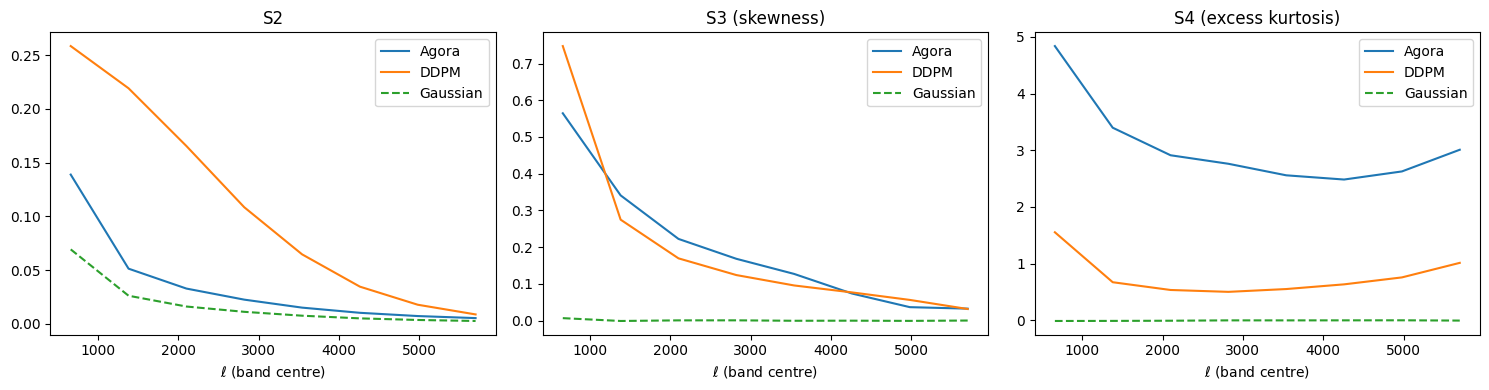

In [36]:
MOMENT_LABELS  = ['S2', 'S3 (skewness)', 'S4 (excess kurtosis)']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, range(3), MOMENT_LABELS):
    ax.plot(bandpass_centers, agora_moments[:, :, col].mean(axis=0),  label="Agora",    color="C0")
    ax.plot(bandpass_centers, ddpm_moments[:, :, col].mean(axis=0),   label="DDPM",     color="C1")
    ax.plot(bandpass_centers, gauss_moments[:, :, col].mean(axis=0),  label="Gaussian", color="C2", ls="--")
    ax.set_xlabel(r"$\ell$ (band centre)");  ax.set_title(label);  ax.legend()
plt.tight_layout();  plt.show()
